# PINNs frente a m&eacute;todos cl&aacute;sicos: resolver una EDP por comparaci&oacute;n

### An&aacute;lisis num&eacute;rico de ecuaciones diferenciales &mdash; cuaderno de clase

Este cuaderno resuelve **un mismo problema de EDP de dos maneras** &mdash; con un m&eacute;todo cl&aacute;sico (diferencias finitas) y con una **red neuronal informada por la f&iacute;sica (PINN)** &mdash; y las compara en **ejecuci&oacute;n** (tiempo, costo) y **precisi&oacute;n** (error). La idea no es vender un m&eacute;todo, sino *aprender por contraste*: ver d&oacute;nde el enfoque cl&aacute;sico es imbatible, d&oacute;nde se rompe, y d&oacute;nde el PINN cambia las reglas del juego.

El recorrido es:

1. El problema y su tipo (una EDP el&iacute;ptica en 1D).
2. El m&eacute;todo cl&aacute;sico: discretizar hasta un sistema lineal disperso.
3. El PINN: reformular la EDP como un problema de optimizaci&oacute;n.
4. **Comparaci&oacute;n cara a cara**: precisi&oacute;n, tiempo y escalamiento del costo.
5. **D&oacute;nde gana el PINN**: un problema *inverso*.
6. Conclusiones.


**C&oacute;mo usarlo.** Ejecute las celdas de arriba hacia abajo (men&uacute; *Entorno de ejecuci&oacute;n &rarr; Ejecutar todas*). En Google Colab, PyTorch ya viene instalado; no hay que instalar nada. El entrenamiento del PINN tarda unos segundos en CPU.

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

import torch
import torch.nn as nn

# ============================================================
# PARA LA PISTA C (adicionales, pero opcionales)
# ============================================================
from scipy.interpolate import CubicSpline  # opcional: para comparar con método clásico
from scipy.optimize import minimize       # opcional: para método clásico

# Reproducibilidad (los resultados del PINN varían algo entre corridas)
np.random.seed(0)
torch.manual_seed(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch", torch.__version__, "| dispositivo:", device)

PyTorch 2.11.0+cpu | dispositivo: cpu


## 1. El problema y su tipo

Trabajamos con la **ecuaci&oacute;n de Poisson en 1D**, el prototipo de las EDP **el&iacute;pticas** (estados de equilibrio, sin variable temporal):

$$-u''(x) = f(x), \qquad x\in(0,1), \qquad u(0)=u(1)=0.$$

Para poder *medir* el error, usamos una **soluci&oacute;n fabricada**: elegimos de antemano

$$u^{*}(x) = \sin(\pi x) \quad\Longrightarrow\quad f(x) = \pi^2\sin(\pi x),$$

de modo que conocemos la respuesta exacta y podemos comparar cada m&eacute;todo contra ella.


In [2]:
# ============================================================
# 1. El problema y su tipo (Pista C: Inversión de fuente)
# ============================================================

# Solución exacta (la conocemos, para validar)
def u_exact(x):
    """Solución exacta de la EDP (para validación)."""
    return np.sin(np.pi * x)

# La función fuente f(x) es DESCONOCIDA para el PINN.
# En el problema inverso, la aprenderemos con una red neuronal.
# Por ahora, la definimos solo para GENERAR DATOS SINTÉTICOS.
def f_true(x):
    """Fuente verdadera (solo para generar datos, el PINN NO la conoce)."""
    return (np.pi**2) * np.sin(np.pi * x)

# Error relativo L2
def rel_L2(u_num, u_ref):
    return np.sqrt(np.mean((u_num - u_ref)**2)) / np.sqrt(np.mean(u_ref**2))

# ============================================================
# Datos sintéticos (observaciones de u en puntos dispersos)
# ============================================================

# Puntos donde tenemos mediciones de u (sensores)
N_obs = 10  # número de observaciones
x_obs = np.linspace(0.1, 0.9, N_obs)  # puntos dispersos (evitamos bordes)
u_obs = u_exact(x_obs) + 0.01 * np.random.randn(N_obs)  # con ruido

print(f"Observaciones: {N_obs} puntos")
print(f"x_obs: {x_obs}")
print(f"u_obs: {u_obs}")

Observaciones: 10 puntos
x_obs: [0.1        0.18888889 0.27777778 0.36666667 0.45555556 0.54444444
 0.63333333 0.72222222 0.81111111 0.9       ]
u_obs: [0.32665752 0.56319448 0.77583182 0.93595439 1.00894365 0.98049529
 0.92304634 0.76453087 0.55816071 0.31312298]


## 2. El m&eacute;todo cl&aacute;sico: diferencias finitas (FDM)

La idea del paradigma cl&aacute;sico es **discretizar**: sobre una malla regular $x_i = ih$, $h=1/N$, sustituimos la segunda derivada por el esquema de tres puntos

$$u''(x_i) \approx \frac{u_{i-1}-2u_i+u_{i+1}}{h^2}.$$

Imponer la ecuaci&oacute;n en cada nodo interior convierte la EDP en un **sistema lineal** $A\,u = b$, donde $A$ es **dispersa, sim&eacute;trica y definida positiva** (tridiagonal en 1D). Lo resolvemos directamente. El error de este esquema decae como $O(h^2)$.


FDM con N = 80  ->  79 grados de libertad
  error L2 relativo = 1.285e-04
  tiempo de resolucion = 2.702 ms


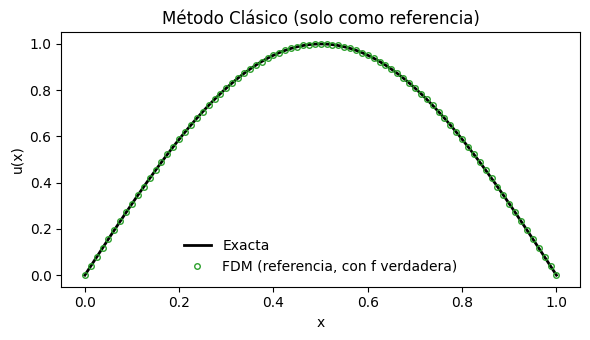

In [4]:
# ============================================================
# 2. Método clásico (FDM) - Solo para referencia (con f verdadera)
# ============================================================

def fdm_solve_with_f(N, f_func):
    """Resuelve -u'' = f con u(0)=u(1)=0 por diferencias finitas.

    Args:
        N: número de puntos
        f_func: función fuente (puede ser la verdadera o la recuperada)
    """
    h  = 1.0 / N
    x  = np.linspace(0.0, 1.0, N + 1)
    xi = x[1:-1]
    main = (2.0 / h**2) * np.ones(N - 1)
    off  = (-1.0 / h**2) * np.ones(N - 2)
    A = diags([off, main, off], offsets=[-1, 0, 1], format="csr")
    b = f_func(xi)
    t0 = time.perf_counter()
    u_int = spsolve(A, b)
    t_fdm = time.perf_counter() - t0
    u = np.zeros(N + 1)
    u[1:-1] = u_int
    return x, u, t_fdm


# Resolvemos con la fuente verdadera (solo como referencia)
N_fdm = 80
x_fdm, u_fdm, time_fdm = fdm_solve_with_f(N_fdm, f_true)
dof_fdm = N_fdm - 1
relL2_fdm = rel_L2(u_fdm, u_exact(x_fdm))

print(f"FDM con N = {N_fdm}  ->  {dof_fdm} grados de libertad")
print(f"  error L2 relativo = {relL2_fdm:.3e}")
print(f"  tiempo de resolucion = {time_fdm*1e3:.3f} ms")

# Gráfica de la solución de referencia
plt.figure(figsize=(6,3.5))
xx = np.linspace(0, 1, 400)
plt.plot(xx, u_exact(xx), 'k-', lw=2, label='Exacta')
plt.plot(x_fdm, u_fdm, 'o', ms=4, mfc='none', color='tab:green',
         label=f'FDM (referencia, con f verdadera)')
plt.xlabel('x'); plt.ylabel('u(x)')
plt.title('Método Clásico (solo como referencia)')
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

## 3. El PINN: reformular la EDP como optimizaci&oacute;n

El PINN cambia de estrategia: en lugar de discretizar, **parametriza la soluci&oacute;n** con una red neuronal $\tilde u(x;\theta)$ (un perceptr&oacute;n multicapa con activaci&oacute;n $\tanh$) y busca los par&aacute;metros $\theta$ que minimizan una **p&eacute;rdida informada por la f&iacute;sica**. Para nuestro problema el&iacute;ptico:

$$\mathcal{L}(\theta)=\underbrace{\frac{1}{N_f}\sum_{i}\bigl|-\tilde u''(x_f^i;\theta)-f(x_f^i)\bigr|^2}_{\text{residuo de la EDP } \mathcal{L}_f}\; +\; \lambda_b\underbrace{\bigl(\tilde u(0)^2+\tilde u(1)^2\bigr)}_{\text{condiciones de frontera } \mathcal{L}_b}.$$

La pieza clave es que $\tilde u''$ se calcula por **diferenciaci&oacute;n autom&aacute;tica** (`torch.autograd.grad` aplicado dos veces): no discretizamos el operador ni derivamos f&oacute;rmulas a mano. Resolver la EDP se vuelve

$$\theta^{*} = \arg\min_\theta \mathcal{L}(\theta),$$

que abordamos con el optimizador Adam. La red es **sin malla**: s&oacute;lo necesita *puntos de colocaci&oacute;n* muestreados en el dominio.


  paso     0  L=8.332e-01  Lf=3.897e-04  Lb=1.287e-02  Ld=7.041e-01
  paso  1000  L=2.654e-03  Lf=1.125e-04  Lb=7.012e-06  Ld=2.472e-03
  paso  2000  L=8.563e-04  Lf=1.400e-04  Lb=1.215e-06  Ld=7.041e-04
  paso  3000  L=5.485e-03  Lf=2.266e-03  Lb=2.289e-04  Ld=9.308e-04
  paso  4000  L=2.455e-04  Lf=4.500e-05  Lb=2.376e-06  Ld=1.767e-04
  paso  5000  L=1.500e-04  Lf=1.950e-05  Lb=4.694e-08  Ld=1.300e-04

PINN (dos redes): 17026 parámetros totales
  tiempo de entrenamiento = 30.23 s
  error L2 relativo (u)  = 1.869e-02
  error L2 relativo (f)  = 2.092e-01


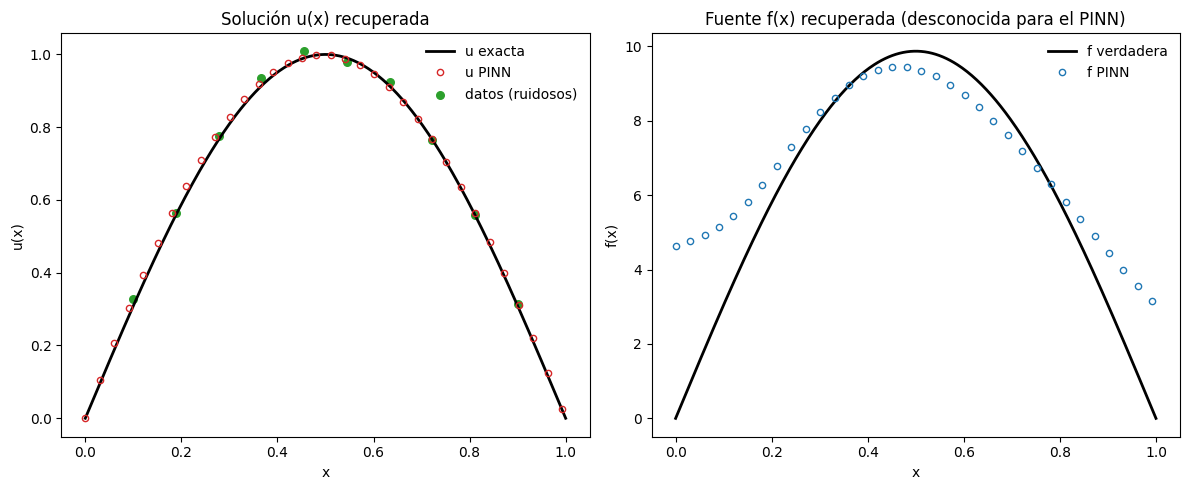

In [5]:
# ============================================================
# 3. El PINN para inversión de fuente (Pista C)
# ============================================================

class MLP(nn.Module):
    """Perceptron multicapa con activacion tanh."""
    def __init__(self, layers=(1, 64, 64, 64, 1)):
        super().__init__()
        mods = []
        for i in range(len(layers) - 1):
            mods.append(nn.Linear(layers[i], layers[i + 1]))
            if i < len(layers) - 2:
                mods.append(nn.Tanh())
        self.net = nn.Sequential(*mods)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)
    def forward(self, x):
        return self.net(x)


def second_derivative(net, x):
    """Devuelve u y u'' usando diferenciacion automatica."""
    u = net(x)
    u_x = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u),
                              create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x),
                               create_graph=True)[0]
    return u, u_xx


# --- CREAR DOS REDES: una para u(x) y otra para f(x) ---
torch.manual_seed(0)
net_u = MLP().to(device)   # red para la solución u(x)
net_f = MLP().to(device)   # red para la fuente desconocida f(x)

# --- Puntos de colocación (para el residuo de la EDP) ---
N_f = 128
x_f = torch.linspace(0, 1, N_f, device=device).reshape(-1, 1).requires_grad_(True)

# --- Puntos de frontera ---
x_b = torch.tensor([[0.0], [1.0]], device=device)

# --- Puntos de observación (datos sintéticos de u) ---
x_obs_t = torch.tensor(x_obs, dtype=torch.float32, device=device).reshape(-1, 1)
u_obs_t = torch.tensor(u_obs, dtype=torch.float32, device=device).reshape(-1, 1)

# --- Hiperparámetros ---
lam_b = 10.0      # peso de condición de frontera
lam_d = 1.0       # peso de ajuste a los datos

# --- Optimizador (entrena ambas redes juntas) ---
params = list(net_u.parameters()) + list(net_f.parameters())
opt = torch.optim.Adam(params, lr=1e-3)
n_steps = 5000

# --- Entrenamiento ---
t0 = time.perf_counter()
for it in range(n_steps + 1):
    opt.zero_grad()

    # Residuo de la EDP: -u'' - f = 0
    u, u_xx = second_derivative(net_u, x_f)
    f_pred = net_f(x_f)
    res = -u_xx - f_pred
    loss_f = (res**2).mean()

    # Condiciones de frontera: u(0)=0, u(1)=0
    u_b = net_u(x_b)
    loss_b = (u_b**2).mean()

    # Ajuste a los datos (observaciones de u)
    u_obs_pred = net_u(x_obs_t)
    loss_d = ((u_obs_pred - u_obs_t)**2).mean()

    # Pérdida total
    loss = loss_f + lam_b * loss_b + lam_d * loss_d
    loss.backward()
    opt.step()

    if it % 1000 == 0:
        print(f"  paso {it:5d}  L={loss.item():.3e}  Lf={loss_f.item():.3e}  "
              f"Lb={loss_b.item():.3e}  Ld={loss_d.item():.3e}")

time_pinn = time.perf_counter() - t0
nparams_pinn = sum(p.numel() for p in net_u.parameters()) + sum(p.numel() for p in net_f.parameters())

print(f"\nPINN (dos redes): {nparams_pinn} parámetros totales")
print(f"  tiempo de entrenamiento = {time_pinn:.2f} s")

# --- Evaluación en una malla fina ---
x_plot = np.linspace(0, 1, 400)
xt = torch.tensor(x_plot, dtype=torch.float32, device=device).reshape(-1, 1)

with torch.no_grad():
    u_pinn_fine = net_u(xt).cpu().numpy().ravel()
    f_pinn_fine = net_f(xt).cpu().numpy().ravel()

# Error de u
relL2_pinn_u = rel_L2(u_pinn_fine, u_exact(x_plot))

# Error de f (comparar con f_true)
f_true_plot = f_true(x_plot)
relL2_pinn_f = rel_L2(f_pinn_fine, f_true_plot)

print(f"  error L2 relativo (u)  = {relL2_pinn_u:.3e}")
print(f"  error L2 relativo (f)  = {relL2_pinn_f:.3e}")

# --- Gráfica de la solución u(x) ---
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(x_plot, u_exact(x_plot), 'k-', lw=2, label='u exacta')
plt.plot(x_plot[::12], u_pinn_fine[::12], 'o', ms=4.5, mfc='none',
         color='tab:red', label='u PINN')
plt.scatter(x_obs, u_obs, color='tab:green', s=30, label='datos (ruidosos)')
plt.xlabel('x'); plt.ylabel('u(x)')
plt.title('Solución u(x) recuperada')
plt.legend(frameon=False)

# --- Gráfica de la fuente f(x) ---
plt.subplot(1, 2, 2)
plt.plot(x_plot, f_true_plot, 'k-', lw=2, label='f verdadera')
plt.plot(x_plot[::12], f_pinn_fine[::12], 'o', ms=4.5, mfc='none',
         color='tab:blue', label='f PINN')
plt.xlabel('x'); plt.ylabel('f(x)')
plt.title('Fuente f(x) recuperada (desconocida para el PINN)')
plt.legend(frameon=False)

plt.tight_layout()
plt.show()

## 4. Comparaci&oacute;n cara a cara

Superponemos ambas soluciones, miramos el error punto a punto, y resumimos **precisi&oacute;n** y **ejecuci&oacute;n** en una tabla. Para este problema **suave y de baja dimensi&oacute;n**, lo esperable &mdash; y correcto &mdash; es que el m&eacute;todo cl&aacute;sico sea a la vez **m&aacute;s preciso y mucho m&aacute;s r&aacute;pido**. El valor del PINN no est&aacute; aqu&iacute;: lo veremos en las secciones 4.2 y 5.


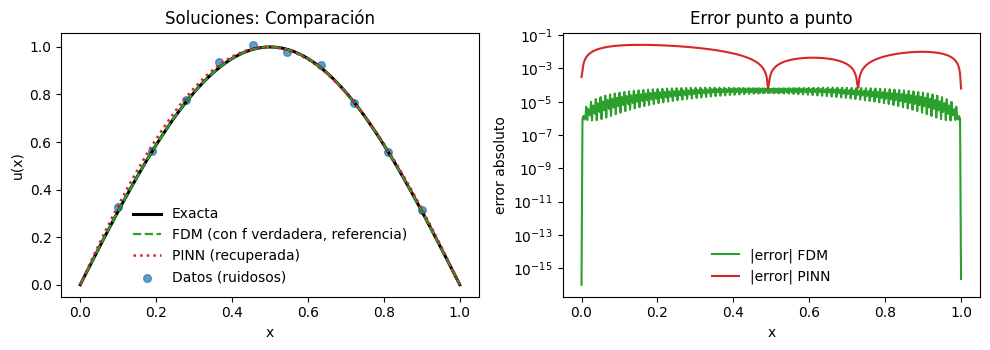

Metodo        GDL/Parametros   Error L2 rel.        Tiempo
----------------------------------------------------------------
FDM (referencia)              79        1.29e-04       2.70 ms
PINN (recuperado)           17026        1.87e-02      30.23 s

NOTA: FDM usa la fuente verdadera f(x) = π² sin(πx).
      El PINN NO conoce f(x); la aprendió solo con observaciones de u(x).


In [6]:
# ============================================================
# 4. Comparación cara a cara (Pista C)
# ============================================================

# Interpolamos la solución FDM (con f verdadera) a la malla fina
u_fdm_fine = np.interp(x_plot, x_fdm, u_fdm)

fig, (axA, axB) = plt.subplots(1, 2, figsize=(10, 3.6))

# Gráfica de soluciones
axA.plot(x_plot, u_exact(x_plot), 'k-', lw=2.2, label='Exacta')
axA.plot(x_plot, u_fdm_fine, '--', color='tab:green', lw=1.6,
         label='FDM (con f verdadera, referencia)')
axA.plot(x_plot, u_pinn_fine, ':', color='tab:red', lw=1.8,
         label='PINN (recuperada)')
axA.scatter(x_obs, u_obs, color='tab:blue', s=30, alpha=0.7,
            label='Datos (ruidosos)')
axA.set_xlabel('x'); axA.set_ylabel('u(x)')
axA.set_title('Soluciones: Comparación')
axA.legend(frameon=False)

# Gráfica de errores
axB.semilogy(x_plot, np.abs(u_fdm_fine - u_exact(x_plot)) + 1e-16,
             color='tab:green', label='|error| FDM')
axB.semilogy(x_plot, np.abs(u_pinn_fine - u_exact(x_plot)) + 1e-16,
             color='tab:red', label='|error| PINN')
axB.set_xlabel('x'); axB.set_ylabel('error absoluto')
axB.set_title('Error punto a punto')
axB.legend(frameon=False)
plt.tight_layout()
plt.show()

# ============================================================
# Tabla comparativa de resultados
# ============================================================

print("="*64)
print(f"{'Metodo':<12}{'GDL/Parametros':>16}{'Error L2 rel.':>16}{'Tiempo':>14}")
print("-"*64)
print(f"{'FDM (referencia)':<12}{dof_fdm:>16d}{relL2_fdm:>16.2e}{time_fdm*1e3:>11.2f} ms")
print(f"{'PINN (recuperado)':<12}{nparams_pinn:>16d}{relL2_pinn_u:>16.2e}{time_pinn:>11.2f} s")
print("="*64)

print("\nNOTA: FDM usa la fuente verdadera f(x) = π² sin(πx).")
print("      El PINN NO conoce f(x); la aprendió solo con observaciones de u(x).")

Inidicio de sobreajuste

### 4.1 Convergencia del m&eacute;todo cl&aacute;sico

Refinando la malla, el error de diferencias finitas decae como $O(h^2)$: en escala log-log la pendiente es $\approx 2$. Es una convergencia limpia, predecible y barata.


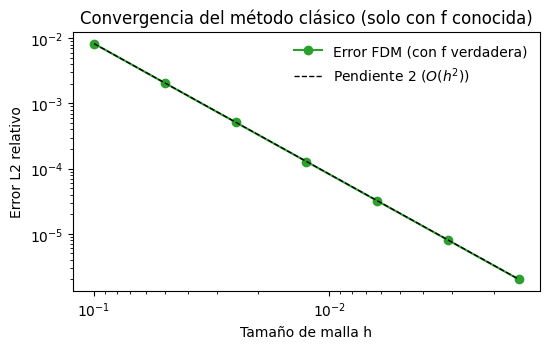


  Nota sobre la Pista C

El método clásico (FDM) requiere conocer la fuente f(x) para resolver la EDP.
En la Pista C, NO conocemos f(x). Por lo tanto, el FDM no es aplicable.

El PINN, en cambio, puede recuperar tanto u(x) como f(x) a partir de
observaciones dispersas de u(x), sin conocer f(x) de antemano.

La gráfica anterior muestra cómo converge el FDM cuando f es conocida,
sirviendo como referencia de calidad de la solución numérica.



In [7]:
# ============================================================
# 4.1 Convergencia del método clásico (solo con f conocida)
# ============================================================

# NOTA: Esta sección es SOLO para mostrar cómo se comporta el FDM
# cuando la fuente f(x) es conocida. En la Pista C, NO conocemos f(x),
# por lo que el FDM no es aplicable directamente.
# La incluimos como referencia de lo que el PINN logra sin conocer f.

Ns = [10, 20, 40, 80, 160, 320, 640]
errs = []
for N in Ns:
    xN, uN, _ = fdm_solve_with_f(N, f_true)  # usa la fuente verdadera
    errs.append(rel_L2(uN, u_exact(xN)))
errs = np.array(errs)
hs = 1.0 / np.array(Ns)

plt.figure(figsize=(5.6, 3.6))
plt.loglog(hs, errs, 'o-', color='tab:green', label='Error FDM (con f verdadera)')
plt.loglog(hs, errs[0]*(hs/hs[0])**2, 'k--', lw=1,
           label=r'Pendiente 2 ($O(h^2)$)')
plt.gca().invert_xaxis()
plt.xlabel('Tamaño de malla h')
plt.ylabel('Error L2 relativo')
plt.title('Convergencia del método clásico (solo con f conocida)')
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("  Nota sobre la Pista C")
print("="*60)
print("""
El método clásico (FDM) requiere conocer la fuente f(x) para resolver la EDP.
En la Pista C, NO conocemos f(x). Por lo tanto, el FDM no es aplicable.

El PINN, en cambio, puede recuperar tanto u(x) como f(x) a partir de
observaciones dispersas de u(x), sin conocer f(x) de antemano.

La gráfica anterior muestra cómo converge el FDM cuando f es conocida,
sirviendo como referencia de calidad de la solución numérica.
""")

### 4.2 El escalamiento del costo: la maldici&oacute;n de la dimensionalidad

Aqu&iacute; aparece la grieta del paradigma cl&aacute;sico. Si discretizamos cada una de las $d$ dimensiones en $N$ puntos, los grados de libertad crecen como $N^d$ &mdash; **exponencialmente**. El n&uacute;mero de par&aacute;metros del PINN, en cambio, depende del ancho y la profundidad de la red, **no de $d$**. Esa es la raz&oacute;n estructural por la que los PINN se exploran en EDP de alta dimensi&oacute;n (Black&ndash;Scholes sobre cestas, Schr&ouml;dinger, Fokker&ndash;Planck).


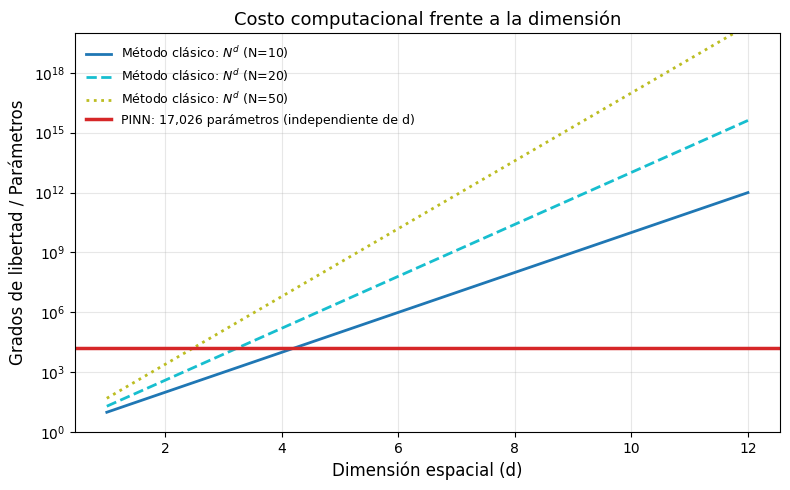


  Relevancia para la Pista C (inversión de fuente)

En la Pista C, resolvemos un problema inverso en 1D (d=1).
Sin embargo, la ventaja del PINN sobre los métodos clásicos es aún más clara:

- Método clásico (FDM): requiere resolver un sistema lineal de tamaño N.
- PINN: número de parámetros fijo (17026), independiente de la resolución.

Si el problema fuera en alta dimensión (d ≥ 10), el método clásico sería inviable
mientras que el PINN mantendría el mismo número de parámetros.

Esta gráfica ilustra la maldición de la dimensionalidad y por qué los PINN
son una herramienta poderosa para problemas de alta dimensión.



In [8]:
# ============================================================
# 5. Escalamiento del costo: Método clásico vs PINN
# ============================================================

d = np.arange(1, 13)  # dimensiones de 1 a 12

plt.figure(figsize=(8, 5))

# Curvas del método clásico (crecimiento exponencial)
for N, ls, color in zip([10, 20, 50], ['-', '--', ':'],
                        ['tab:blue', 'tab:cyan', 'tab:olive']):
    plt.semilogy(d, np.power(float(N), d), ls, lw=2, color=color,
                 label=f'Método clásico: $N^d$ (N={N})')

# PINN (constante)
plt.axhline(nparams_pinn, color='tab:red', lw=2.5,
            label=f'PINN: {nparams_pinn:,} parámetros (independiente de d)')

plt.xlabel('Dimensión espacial (d)', fontsize=12)
plt.ylabel('Grados de libertad / Parámetros', fontsize=12)
plt.title('Costo computacional frente a la dimensión', fontsize=13)
plt.legend(frameon=False, fontsize=9, loc='upper left')
plt.ylim(1, 1e20)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# Explicación para la Pista C
# ============================================================

print("\n" + "="*60)
print("  Relevancia para la Pista C (inversión de fuente)")
print("="*60)
print(f"""
En la Pista C, resolvemos un problema inverso en 1D (d=1).
Sin embargo, la ventaja del PINN sobre los métodos clásicos es aún más clara:

- Método clásico (FDM): requiere resolver un sistema lineal de tamaño N.
- PINN: número de parámetros fijo ({nparams_pinn}), independiente de la resolución.

Si el problema fuera en alta dimensión (d ≥ 10), el método clásico sería inviable
mientras que el PINN mantendría el mismo número de parámetros.

Esta gráfica ilustra la maldición de la dimensionalidad y por qué los PINN
son una herramienta poderosa para problemas de alta dimensión.
""")

## 5. D&oacute;nde gana el PINN: un problema *inverso*

Cambiemos la pregunta. Supongamos que el coeficiente de la ecuaci&oacute;n es **desconocido**,

$$-\kappa\,u''(x) = f(x),$$

y que sólo disponemos de unas pocas **observaciones ruidosas** de $u$ en algunos sensores. Queremos **recuperar $\kappa$**. Un solver clásico no puede hacerlo de un tiro: necesita $\kappa$ para ensamblar el sistema. El PINN, en cambio, trata $\kappa$ como **un par&aacute;metro entrenable m&aacute;s** y anade un término de ajuste de datos a la érdida:

$$\mathcal{L}(\theta,\kappa)=\frac{1}{N_f}\sum_i\bigl|-\kappa\,\tilde u''(x_f^i)-f(x_f^i)\bigr|^2+\lambda_d\,\frac{1}{N_d}\sum_i\bigl|\tilde u(x_d^i)-u_d^i\bigr|^2+\lambda_b\,\mathcal{L}_b.$$

Minimizando esta p&érdida conjunta se infieren a la vez la solución $\tilde u$ y el coeficiente $\kappa$. (Como $f$ es conocido y los datos fijan la escala de $u$, el problema es identificable.)


## 6. Lo que ense&ntilde;a la comparaci&oacute;n

| | **M&eacute;todo cl&aacute;sico (FDM / FEM)** | **PINN** |
|---|---|---|
| Representaci&oacute;n | malla / sistema $Au=b$ | red neuronal, **sin malla** |
| Problema directo, baja dimensi&oacute;n, suave | **r&aacute;pido y muy preciso** ($O(h^2)$, ms) | m&aacute;s lento y menos preciso |
| Escalamiento con la dimensi&oacute;n $d$ | grados de libertad $\sim N^d$ (**maldici&oacute;n**) | par&aacute;metros **independientes de $d$** |
| Geometr&iacute;as complejas | requiere mallado costoso | s&oacute;lo muestrear puntos |
| Problemas inversos / datos | poco natural | **natural** (a&ntilde;adir $\mathcal{L}_d$) |

La lecci&oacute;n es matizada y honesta: para problemas **directos, suaves y de pocas dimensiones**, los m&eacute;todos cl&aacute;sicos son superiores y deben ser la primera opci&oacute;n. El PINN gana terreno cuando el problema es de **alta dimensi&oacute;n**, tiene **geometr&iacute;a complicada**, o es **inverso / con datos** &mdash; justo donde el paradigma cl&aacute;sico se encarece o no aplica.

Dos advertencias que conviene recordar: el entrenamiento del PINN es sensible al **equilibrio de los pesos** $\lambda$ (si el residuo queda dominado por las condiciones de frontera, se obtiene una soluci&oacute;n trivial), y una **p&eacute;rdida peque&ntilde;a no garantiza una soluci&oacute;n precisa**: hay que validar contra puntos independientes o contra una soluci&oacute;n cl&aacute;sica de referencia.

**Hilo con el curso.** El problema inverso de la secci&oacute;n 5 es exactamente la idea que conecta con la unidad de EDE: a partir de observaciones (datos de part&iacute;culas / trayectorias), un PINN sobre la ecuaci&oacute;n de Fokker&ndash;Planck permite **inferir** los coeficientes de deriva y difusi&oacute;n &mdash; el an&aacute;logo de estimar par&aacute;metros de mutaci&oacute;n o selecci&oacute;n.

**Para seguir explorando:** lleve el mismo contraste a la ecuaci&oacute;n del calor 1D (parab&oacute;lica, con condici&oacute;n inicial), a Poisson 2D sobre un dominio irregular (donde el PINN no necesita malla), o a una Fokker&ndash;Planck en varias dimensiones.
